(100, 1) (100,)


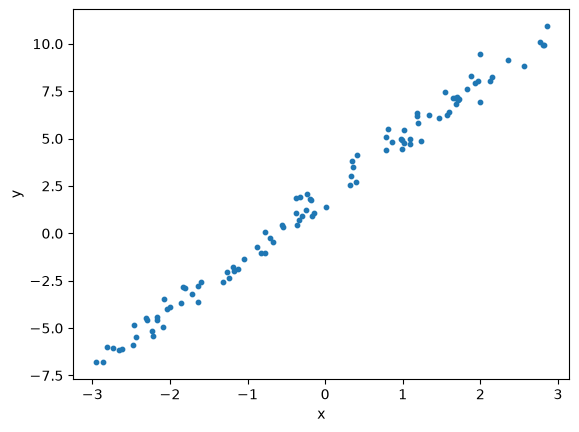

In [13]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

n = 100;
X = rng.uniform(-3, 3, size = (n,1))
y = 3 * X[:, 0] + 2 + rng.normal(0, 0.5, size =  n)

print(X.shape, y.shape)
plt.scatter(X[:, 0], y, s=10)
plt.xlabel("x"); plt.ylabel("y"); plt.show()


In [ ]:
def predict(X, w, b):
    return X @ w + b

def loss(y_pred, y):
    return np.mean((y_pred - y)**2)
    
def gradients(X, y, w, b):
    n = len(n)
    y_hat = predict(X, w, b)
    e = y_hat - y

    dw = 2 / n * (X.T @ e)
    db = 2 / n * e.sum()

    return dw, db

    

[ 6.28747258  2.26654128  7.30317504  5.36841635 -1.86987183  8.70746822
  6.13367642  6.43277166 -1.46263641  2.40463125  1.44957629  8.12117987
  4.72638144  6.87313936  2.32097039 -0.27313534  3.65501744 -2.23419293
  6.93157406  4.57997279  6.09705288  1.25431162  8.64837629  7.71745346
  6.34060196 -0.66433551  2.60065204 -2.47435481 -1.1485261   5.19658744
  5.93714587  8.61011679  0.9099043   1.44551647  2.63466974 -0.72634369
 -1.44094194  2.70845911 -0.27708781  5.03776794  2.24582303  6.99213835
  5.40318122  0.7483997   6.98711762  6.65717229  1.64974055  0.45993725
  5.18994605 -1.3229702  -0.60110157 -2.91165276  6.44309253  4.97821028
  5.46198454  6.36874837  2.50698931  3.82489435 -1.32243602 -1.62563912
  5.02083554  2.65315447  3.78283328  6.17998629  4.61661984  3.64295281
  3.71048593  0.64740118 -2.63018599  2.24060867 -0.42498393  1.90234372
  7.24083688 -0.19272617 -2.3003671   0.3766067   0.52312509  4.94299818
  3.68438583  6.40677851  4.97176248  1.87664234  6

(array([-5.54384353]), np.float64(2.173381739265399))

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
[ 2.94201306e-02 -2.27335198e-03  3.74260242e-02  2.21760147e-02
 -3.48770765e-02  4.84948384e-02  2.82078901e-02  3.05653961e-02
 -3.16671961e-02 -1.18490953e-03 -8.71277201e-03  4.38736404e-02
  1.71154153e-02  3.40364293e-02 -1.84433495e-03 -2.22914002e-02
  8.67079054e-03 -3.77487010e-02  3.44970190e-02  1.59614041e-02
  2.79192188e-02 -1.02518725e-02  4.80290685e-02  4.06914184e-02
  2.98389031e-02 -2.53748887e-02  3.60150811e-04 -3.96416869e-02
 -2.91913394e-02  2.08216377e-02  2.66588118e-02  4.77275023e-02
 -1.29665340e-02 -8.74477201e-03  6.28282496e-04 -2.58636450e-02
 -3.14961976e-02  1.20989960e-03 -2.23225541e-02  1.95698026e-02
 -2.43665582e-03  3.49743942e-02  2.24500357

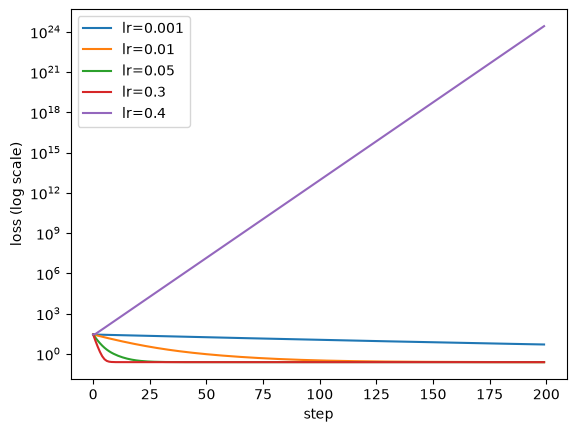

In [22]:
def train(lr, steps = 200):
    w = np.zeros(1)
    b = 0.0
    losses = []

    for _ in range(steps):
        losses.append(loss(predict(X, w, b), y))

        dw, db = gradients(X, y, w, b)
        w = w - lr * dw
        b = b - lr * db

    return w , b , losses

for lr in [0.001, 0.01, 0.05, 0.3, 0.4]:
    w_, b_, losses_ = train(lr)
    print(f"lr={lr}: final loss={losses_[-1]:.4f}, w={w_}, b={b_:.3f}")
    plt.plot(losses_, label=f"lr={lr}")

plt.yscale("log")
plt.legend(); plt.xlabel("step"); plt.ylabel("loss (log scale)"); plt.show()

In [24]:
def numerical_gradients(X, y, w, b, eps = 1e-5):
    dw_num = np.zeros_like(w)

    for i in range(len(w)):
        w_plus, w_minus = w.copy() , w.copy()
        w_plus[i] += eps
        w_minus[i] -= eps
        
        dw_num[i] = (loss(predict(X, w_plus, b), y) - loss(predict(X, w_minus, b), y)) / (2 * eps)

    db_num = np.zeros_like(b)

    db_num = (loss(predict(X, w, b + eps), y) - loss(predict(X, w, b - eps), y)) / (2 * eps)
    return dw_num, db_num

w_test = np.array([1.5])
b_test = -0.7

dw, db = gradients(X, y, w_test, b_test)
dw_num, db_num = numerical_gradients(X, y, w_test, b_test)

print("analytic :", dw, db)
print("numerical:", dw_num, db_num)
print("max difference:", max(abs(dw - dw_num).max(), abs(db - db_num)))
        
    

[ 1.76560444 -1.25009404  2.52738128  1.07631226 -4.35240387  3.58060116
  1.65025732  1.87457875 -4.04697731 -1.14652656 -1.86281778  3.1408849
  0.59478608  2.20485452 -1.20927221 -3.1548515  -0.20873692 -4.6256447
  2.24868055  0.48497959  1.62278966 -2.00926629  3.53628222  2.83809009
  1.80545147 -3.44825163 -0.99951097 -4.80576611 -3.81139457  0.94744058
  1.5028594   3.50758759 -2.26757178 -1.86586265 -0.9739977  -3.49475777
 -4.03070645 -0.91865566 -3.15781586  0.82832595 -1.26563273  2.29410376
  1.10238592 -2.38870023  2.29033821  2.04287922 -1.71269459 -2.60504706
  0.94245954 -3.94222765 -3.40082618 -5.13373957  1.8823194   0.78365771
  1.14648841  1.82656128 -1.06975802 -0.08132924 -3.94182702 -4.16922934
  0.81562666 -0.96013414 -0.11287504  1.68498972  0.51246488 -0.21778539
 -0.16713555 -2.46444912 -4.92263949 -1.2695435  -3.26873794 -1.52324221
  2.48062766 -3.09454463 -4.67527532 -2.66754497 -2.55765618  0.75724863
 -0.18671063  1.85508388  0.77882186 -1.54251825  2.1

In [25]:
from sklearn.linear_model import LinearRegression

w_mine, b_mine, _ = train(lr=0.05, steps=500)

model = LinearRegression().fit(X, y)

print("mine   :", w_mine, b_mine)
print("sklearn:", model.coef_, model.intercept_)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
[ 1.47100653 -0.1136676   1.87130121  1.10880073 -1.74385383  2.42474192
  1.41039451  1.52826981 -1.58335981 -0.05924548 -0.4356386   2.19368202
  0.85577077  1.70182147 -0.09221675 -1.11457001  0.43353953 -1.88743505
  1.72485095  0.7980702   1.39596094 -0.51259363  2.40145342  2.03457092
  1.49194515 -1.26874444  0.01800754 -1.98208435 -1.45956697  1.04108189
  1.33294059  2.38637512 -0.6483267  -0.4372386   0.03141412 -1.29318225
 -1.57480988  0.06049498 -1.1161277   0.97849013 -0.12183279  1.74871971
  1.12250179 -0.71197667  1.74674101  1.6167075  -0.35675262 -0.82566153
  1.03846447 -1.52831648 -1.24382355 -2.1544262   1.53233733  0.95501808
  1.14567654  1.50303783 -0.01890553 